In [22]:
import pandas as pd
import joblib
import os
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn import tree
from tqdm import tqdm
import numpy as np

# 1. โหลดข้อมูล
df = pd.read_csv('data/cleaned_features_ready_to_train.csv')
X = df.drop(columns=['Target_Dangerous'])
if 'AnimalName' in X.columns: X = X.drop(columns=['AnimalName'])
y = df['Target_Dangerous']

# 2. แบ่งข้อมูล
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Data Loaded: {X_train.shape[0]} samples for training, {X_test.shape[0]} for testing.")

Data Loaded: 1022 samples for training, 256 for testing.


In [23]:
# ตั้งค่า Folder
model_path = 'models/randomforest'
if not os.path.exists(model_path): os.makedirs(model_path)

# เทรนแบบ Warm Start เพื่อดึงค่า Accuracy ระหว่างทาง
n_trees = 100
model = RandomForestClassifier(n_estimators=1, warm_start=True, random_state=42, class_weight='balanced')

train_scores = []
test_scores = []

print("🚀 Training Random Forest...")
for i in tqdm(range(1, n_trees + 1)):
    model.n_estimators = i
    model.fit(X_train, y_train)
    
    # เก็บค่าไปพลอต Graph 1
    train_scores.append(model.score(X_train, y_train))
    test_scores.append(model.score(X_test, y_test))

# บันทึกโมเดล
joblib.dump(model, f'{model_path}/animal_risk_model.pkl')
joblib.dump(X.columns.tolist(), f'{model_path}/feature_columns.pkl')
print(f"✅ Model saved to {model_path}")

🚀 Training Random Forest...


  0%|          | 0/100 [00:00<?, ?it/s]e:\KU\KU3-2\ML\Project\Danger\.venv\lib\site-packages\sklearn\ensemble\_forest.py:860: UserWarning: class_weight presets "balanced" or "balanced_subsample" are not recommended for warm_start if the fitted data differs from the full dataset. In order to use "balanced" weights, use compute_class_weight ("balanced", classes, y). In place of y you can use a large enough sample of the full training set target to properly estimate the class frequency distributions. Pass the resulting weights as the class_weight parameter.
  warn(
e:\KU\KU3-2\ML\Project\Danger\.venv\lib\site-packages\sklearn\ensemble\_forest.py:860: UserWarning: class_weight presets "balanced" or "balanced_subsample" are not recommended for warm_start if the fitted data differs from the full dataset. In order to use "balanced" weights, use compute_class_weight ("balanced", classes, y). In place of y you can use a large enough sample of the full training set target to properly estimate th

✅ Model saved to models/randomforest


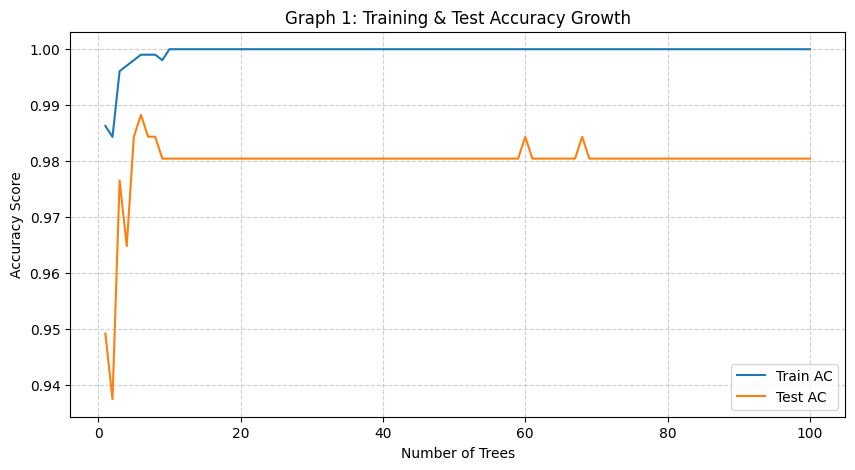

C:\Users\user\AppData\Local\Temp\ipykernel_26348\903330653.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=importances, palette='magma')


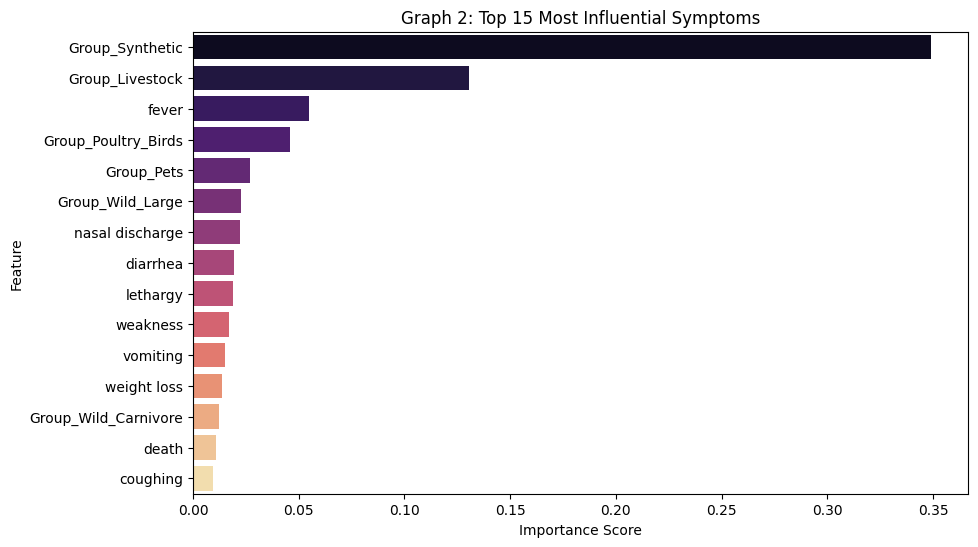

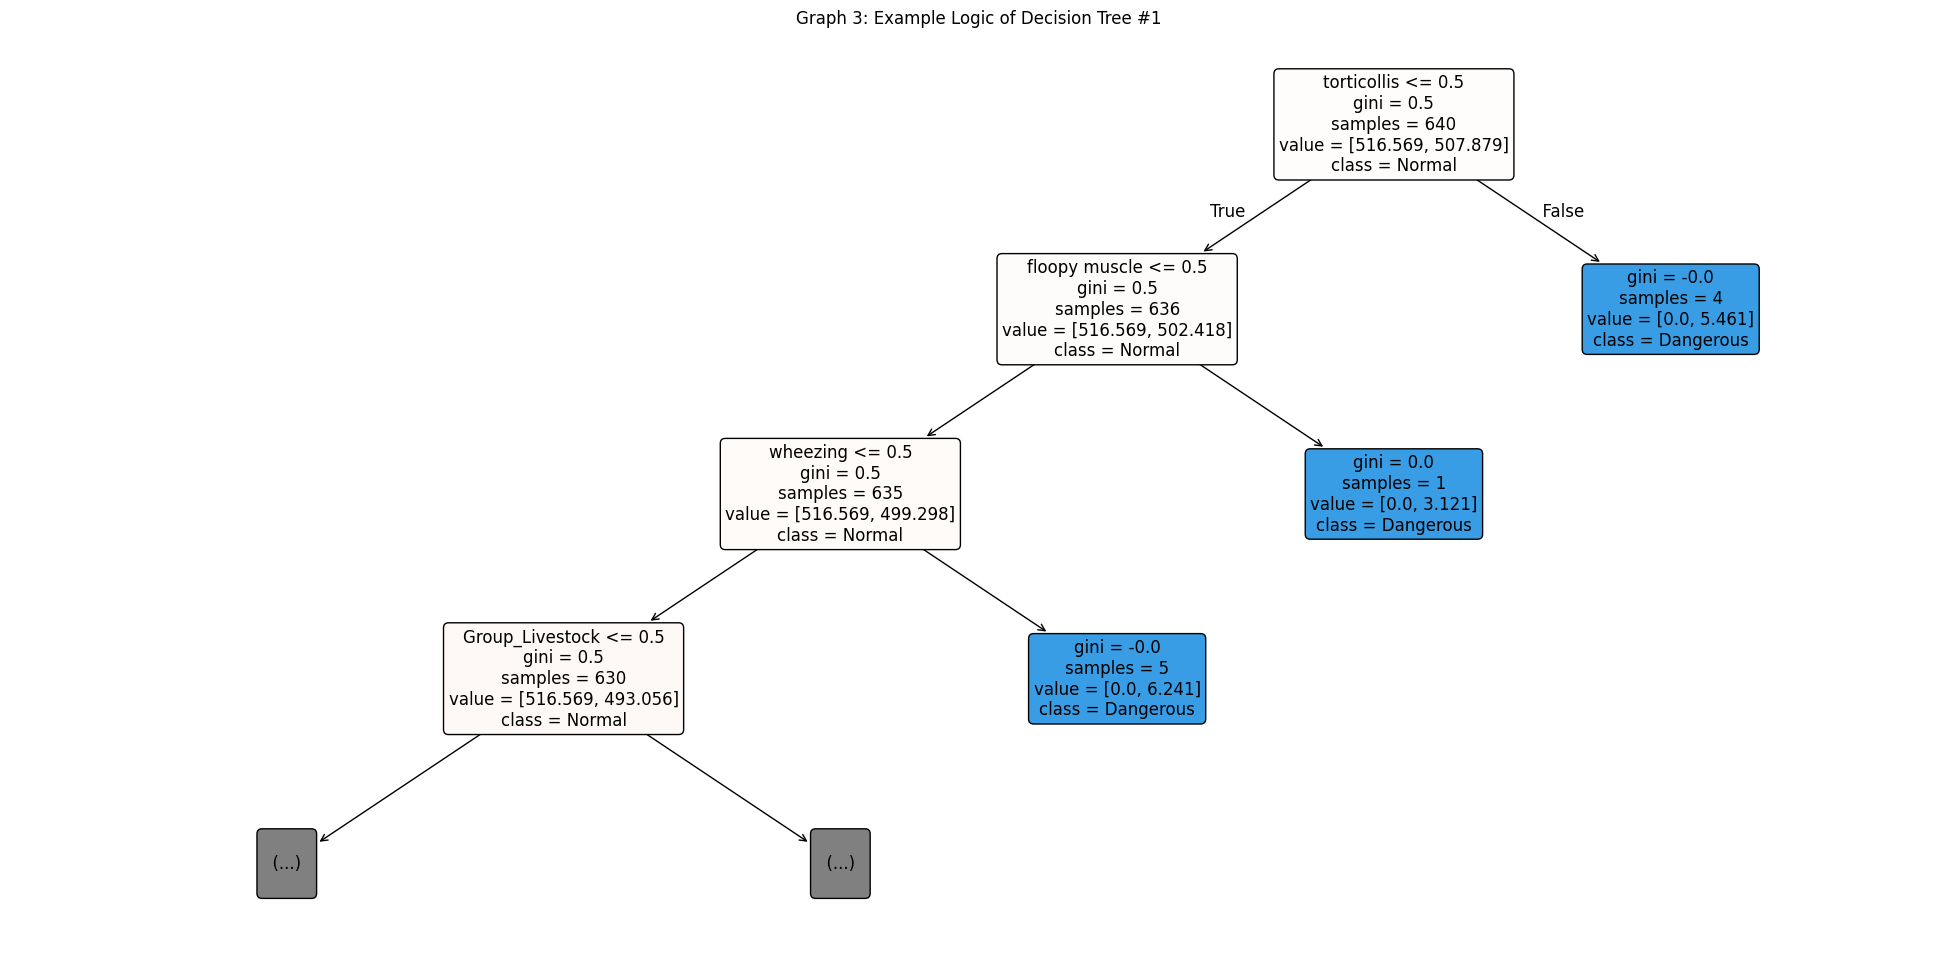

In [24]:
# --- Graph 1: Training Graph (Learning Curve) ---
plt.figure(figsize=(10, 5))
plt.plot(range(1, n_trees + 1), train_scores, label='Train AC', color='#1f77b4')
plt.plot(range(1, n_trees + 1), test_scores, label='Test AC', color='#ff7f0e')
plt.title('Graph 1: Training & Test Accuracy Growth')
plt.xlabel('Number of Trees')
plt.ylabel('Accuracy Score')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

# --- Graph 2: Feature Importance (Explainable AI) ---
importances = pd.DataFrame({
    'Feature': X.columns,
    'Importance': model.feature_importances_
}).sort_values(by='Importance', ascending=False).head(15)

plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=importances, palette='magma')
plt.title('Graph 2: Top 15 Most Influential Symptoms')
plt.xlabel('Importance Score')
plt.show()

# --- Graph 3: Decision Tree Visual (Logic Structure) ---
plt.figure(figsize=(25, 12))
tree.plot_tree(model.estimators_[0], 
               feature_names=X.columns,  
               class_names=['Normal', 'Dangerous'],
               filled=True, 
               max_depth=3, # ดูแค่ 3 ชั้นแรกเพื่อความชัดเจน
               fontsize=12,
               rounded=True)
plt.title('Graph 3: Example Logic of Decision Tree #1')
plt.show()


🔍 กำลังวิเคราะห์อาการเสี่ยงรายกลุ่มสัตว์...


C:\Users\user\AppData\Local\Temp\ipykernel_26348\971304415.py:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=risk_logic.values, y=risk_logic.index, palette='flare')


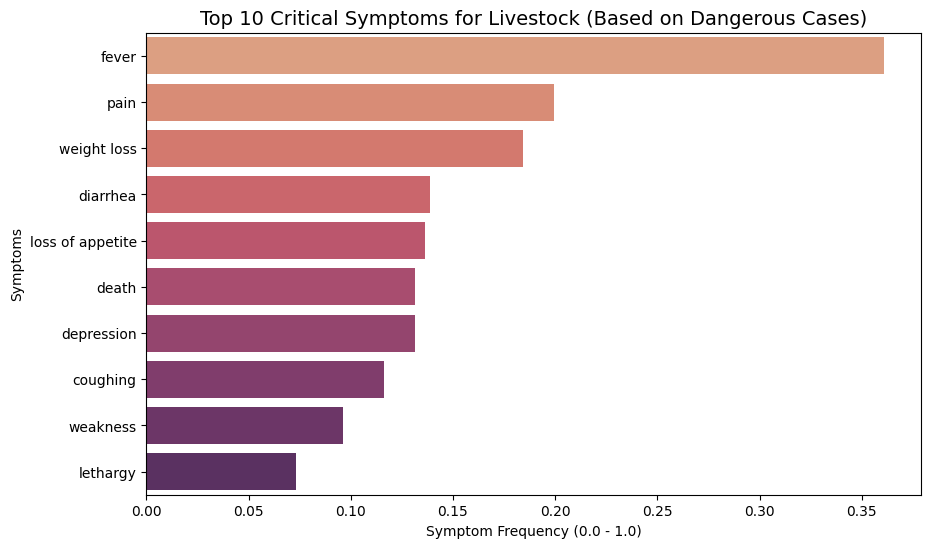

✅ สรุปอาการเสี่ยงของกลุ่ม Livestock:
   1. fever (พบความบ่อย 36.1%)
   2. pain (พบความบ่อย 19.9%)
   3. weight loss (พบความบ่อย 18.4%)
   4. diarrhea (พบความบ่อย 13.9%)
   5. loss of appetite (พบความบ่อย 13.6%)
   6. death (พบความบ่อย 13.1%)
   7. depression (พบความบ่อย 13.1%)
   8. coughing (พบความบ่อย 11.6%)
   9. weakness (พบความบ่อย 9.6%)
   10. lethargy (พบความบ่อย 7.3%)
--------------------------------------------------


C:\Users\user\AppData\Local\Temp\ipykernel_26348\971304415.py:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=risk_logic.values, y=risk_logic.index, palette='flare')


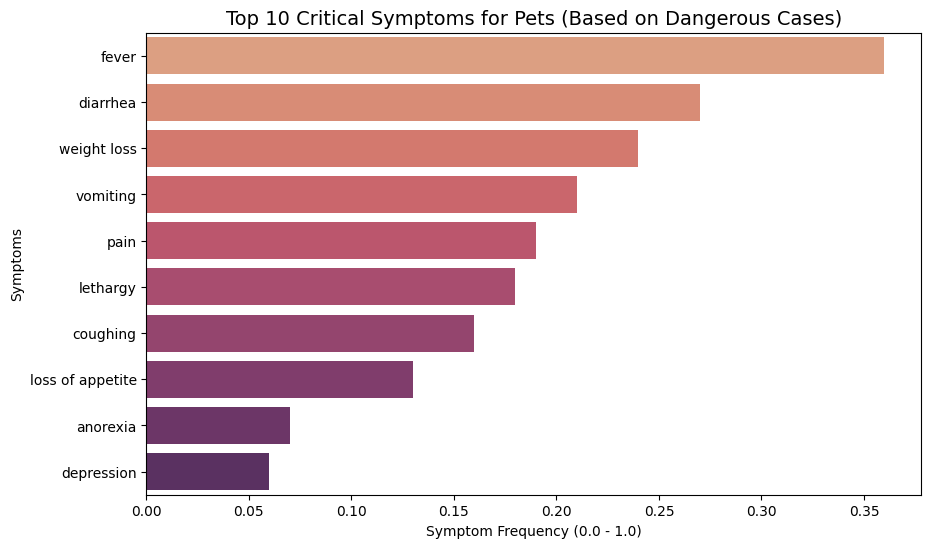

C:\Users\user\AppData\Local\Temp\ipykernel_26348\971304415.py:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=risk_logic.values, y=risk_logic.index, palette='flare')


✅ สรุปอาการเสี่ยงของกลุ่ม Pets:
   1. fever (พบความบ่อย 36.0%)
   2. diarrhea (พบความบ่อย 27.0%)
   3. weight loss (พบความบ่อย 24.0%)
   4. vomiting (พบความบ่อย 21.0%)
   5. pain (พบความบ่อย 19.0%)
   6. lethargy (พบความบ่อย 18.0%)
   7. coughing (พบความบ่อย 16.0%)
   8. loss of appetite (พบความบ่อย 13.0%)
   9. anorexia (พบความบ่อย 7.0%)
   10. depression (พบความบ่อย 6.0%)
--------------------------------------------------


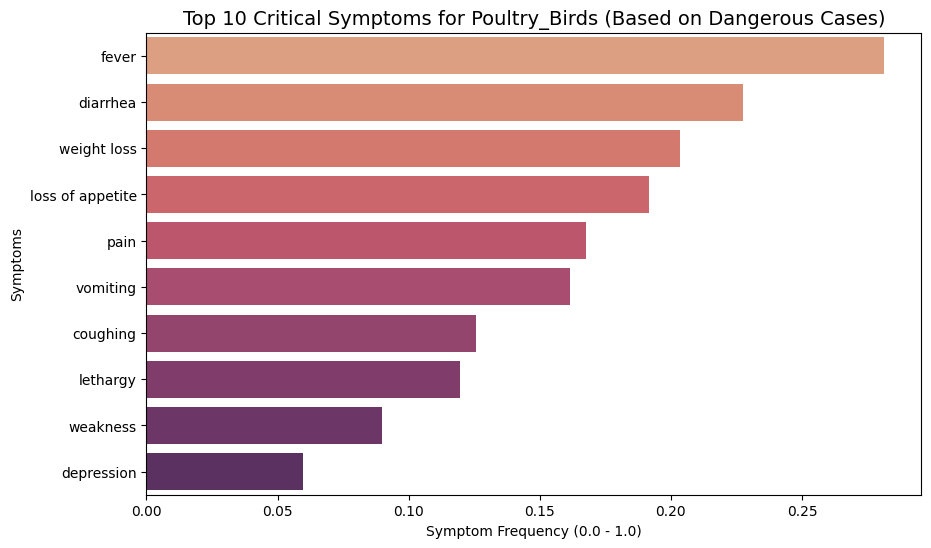

✅ สรุปอาการเสี่ยงของกลุ่ม Poultry_Birds:
   1. fever (พบความบ่อย 28.1%)
   2. diarrhea (พบความบ่อย 22.8%)
   3. weight loss (พบความบ่อย 20.4%)
   4. loss of appetite (พบความบ่อย 19.2%)
   5. pain (พบความบ่อย 16.8%)
   6. vomiting (พบความบ่อย 16.2%)
   7. coughing (พบความบ่อย 12.6%)
   8. lethargy (พบความบ่อย 12.0%)
   9. weakness (พบความบ่อย 9.0%)
   10. depression (พบความบ่อย 6.0%)
--------------------------------------------------


C:\Users\user\AppData\Local\Temp\ipykernel_26348\971304415.py:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=risk_logic.values, y=risk_logic.index, palette='flare')


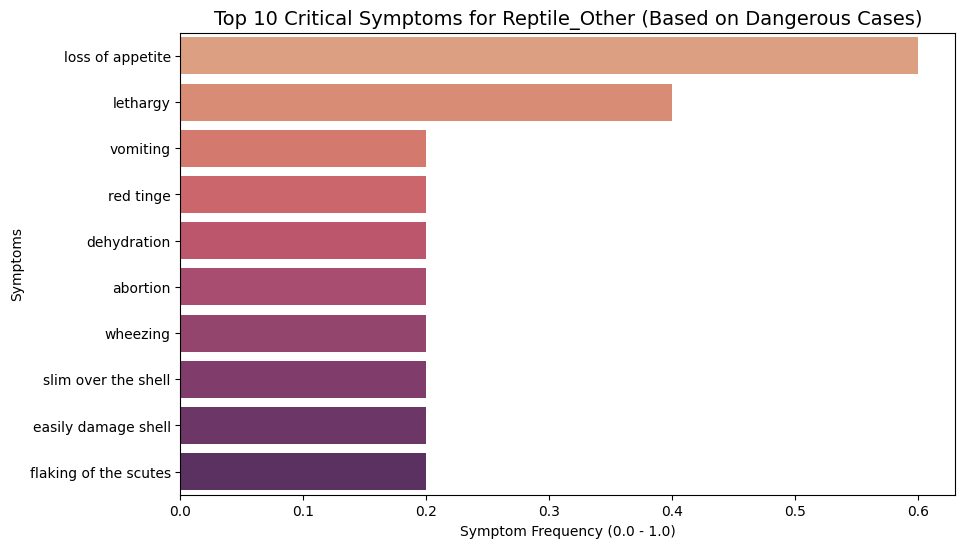

✅ สรุปอาการเสี่ยงของกลุ่ม Reptile_Other:
   1. loss of appetite (พบความบ่อย 60.0%)
   2. lethargy (พบความบ่อย 40.0%)
   3. vomiting (พบความบ่อย 20.0%)
   4. red tinge (พบความบ่อย 20.0%)
   5. dehydration (พบความบ่อย 20.0%)
   6. abortion (พบความบ่อย 20.0%)
   7. wheezing (พบความบ่อย 20.0%)
   8. slim over the shell (พบความบ่อย 20.0%)
   9. easily damage shell (พบความบ่อย 20.0%)
   10. flaking of the scutes (พบความบ่อย 20.0%)
--------------------------------------------------
⚠️ กลุ่ม Synthetic: ไม่พบข้อมูลสัตว์ที่อยู่ในเกณฑ์อันตรายใน Dataset


C:\Users\user\AppData\Local\Temp\ipykernel_26348\971304415.py:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=risk_logic.values, y=risk_logic.index, palette='flare')


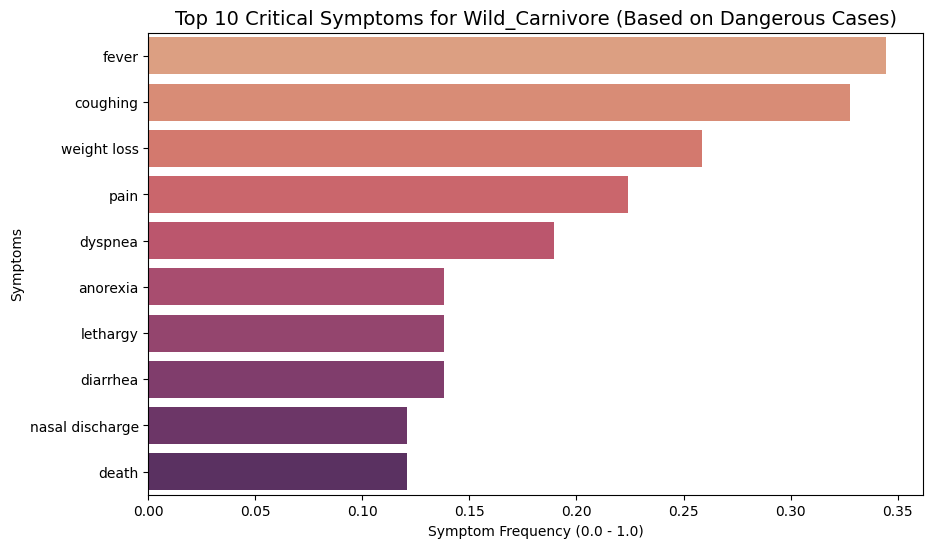

✅ สรุปอาการเสี่ยงของกลุ่ม Wild_Carnivore:
   1. fever (พบความบ่อย 34.5%)
   2. coughing (พบความบ่อย 32.8%)
   3. weight loss (พบความบ่อย 25.9%)
   4. pain (พบความบ่อย 22.4%)
   5. dyspnea (พบความบ่อย 19.0%)
   6. anorexia (พบความบ่อย 13.8%)
   7. lethargy (พบความบ่อย 13.8%)
   8. diarrhea (พบความบ่อย 13.8%)
   9. nasal discharge (พบความบ่อย 12.1%)
   10. death (พบความบ่อย 12.1%)
--------------------------------------------------


C:\Users\user\AppData\Local\Temp\ipykernel_26348\971304415.py:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=risk_logic.values, y=risk_logic.index, palette='flare')


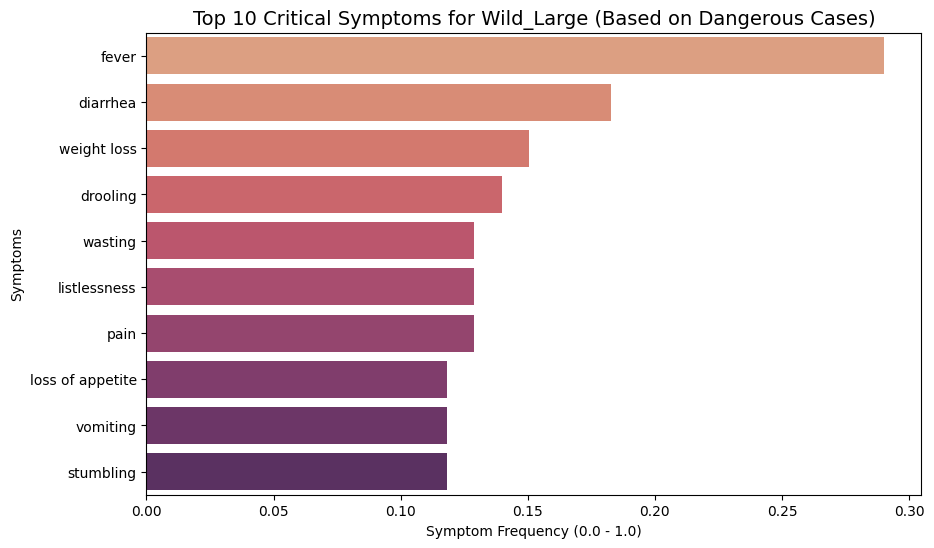

✅ สรุปอาการเสี่ยงของกลุ่ม Wild_Large:
   1. fever (พบความบ่อย 29.0%)
   2. diarrhea (พบความบ่อย 18.3%)
   3. weight loss (พบความบ่อย 15.1%)
   4. drooling (พบความบ่อย 14.0%)
   5. wasting (พบความบ่อย 12.9%)
   6. listlessness (พบความบ่อย 12.9%)
   7. pain (พบความบ่อย 12.9%)
   8. loss of appetite (พบความบ่อย 11.8%)
   9. vomiting (พบความบ่อย 11.8%)
   10. stumbling (พบความบ่อย 11.8%)
--------------------------------------------------


In [28]:
# --- ส่วนที่เพิ่ม: วิเคราะห์ 10 อาการเสี่ยงแยกตามกลุ่มสัตว์ ---

# 1. ระบุรายชื่อกลุ่มสัตว์ที่มีในข้อมูล (คอลัมน์ที่ขึ้นต้นด้วย Group_)
group_cols = [col for col in X.columns if col.startswith('Group_')]

print("\n🔍 กำลังวิเคราะห์อาการเสี่ยงรายกลุ่มสัตว์...")

# สร้างโฟลเดอร์สำหรับเก็บรูปภาพแยกกลุ่ม (ถ้าต้องการ)
output_img_path = 'models/symptom_analysis'
if not os.path.exists(output_img_path): os.makedirs(output_img_path)

for group in group_cols:
    group_name = group.replace('Group_', '')
    
    # 2. กรองข้อมูลเฉพาะกลุ่มสัตว์นั้นๆ
    # เราจะดูจาก X_train หรือ X ก็ได้ แต่ดูจากเคสที่ Target_Dangerous == 1 (อันตรายจริง)
    mask = (df[group] == 1) & (df['Target_Dangerous'] == 1)
    df_group_risk = df[mask]
    
    if len(df_group_risk) > 0:
        # 3. เลือกเฉพาะคอลัมน์ที่เป็นอาการ (ไม่ใช่คอลัมน์ Group และไม่ใช่ Target)
        symptom_cols = [col for col in X.columns if not col.startswith('Group_')]
        
        # คำนวณความถี่ของอาการในกลุ่มเสี่ยง (ค่าเฉลี่ย)
        risk_logic = df_group_risk[symptom_cols].mean().sort_values(ascending=False).head(10)
        
        # 4. พลอตกราฟแยกตามกลุ่มสัตว์
        plt.figure(figsize=(10, 6))
        sns.barplot(x=risk_logic.values, y=risk_logic.index, palette='flare')
        plt.title(f'Top 10 Critical Symptoms for {group_name} (Based on Dangerous Cases)', fontsize=14)
        plt.xlabel('Symptom Frequency (0.0 - 1.0)')
        plt.ylabel('Symptoms')
        
        # บันทึกรูปภาพแยกตามกลุ่ม
        plt.savefig(f'{output_img_path}/{group_name}_top_symptoms.png')
        plt.show()
        
        print(f"✅ สรุปอาการเสี่ยงของกลุ่ม {group_name}:")
        for i, (sym, val) in enumerate(risk_logic.items(), 1):
            print(f"   {i}. {sym} (พบความบ่อย {val*100:.1f}%)")
        print("-" * 50)
    else:
        print(f"⚠️ กลุ่ม {group_name}: ไม่พบข้อมูลสัตว์ที่อยู่ในเกณฑ์อันตรายใน Dataset")

In [29]:
# เช็คจำนวนข้อมูลกลุ่ม Synthetic แยกตามความเสี่ยง
print("🔍 ตรวจสอบกลุ่ม Synthetic:")
synthetic_check = df[df['Group_Synthetic'] == 1]['Target_Dangerous'].value_counts()
print(synthetic_check)

if len(synthetic_check) == 0:
    print("❌ ไม่มีสัตว์ในกลุ่ม Synthetic เลยในไฟล์ CSV นี้")
elif 1 not in synthetic_check.index:
    print("⚠️ มีสัตว์กลุ่ม Synthetic แต่ 'ไม่มีตัวไหนที่อันตราย (1)' เลย กราฟจึงไม่โชว์")

🔍 ตรวจสอบกลุ่ม Synthetic:
Target_Dangerous
0    439
Name: count, dtype: int64
⚠️ มีสัตว์กลุ่ม Synthetic แต่ 'ไม่มีตัวไหนที่อันตราย (1)' เลย กราฟจึงไม่โชว์


📊 Detailed Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.95      0.97        92
           1       0.97      1.00      0.98       164

    accuracy                           0.98       256
   macro avg       0.99      0.97      0.98       256
weighted avg       0.98      0.98      0.98       256



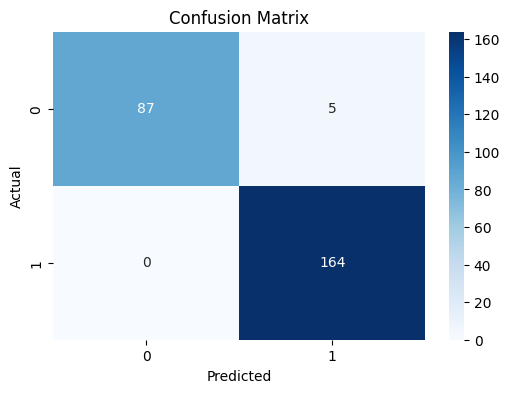

In [25]:
y_pred = model.predict(X_test)
print("📊 Detailed Classification Report:")
print(classification_report(y_test, y_pred))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

In [26]:
from sklearn.tree import export_text

# ดึงต้นไม้ต้นแรก (index 0) ออกมาดูกฎ
tree_rules = export_text(model.estimators_[0], feature_names=X.columns.tolist())
print(tree_rules)

|--- torticollis <= 0.50
|   |--- floopy muscle <= 0.50
|   |   |--- wheezing <= 0.50
|   |   |   |--- Group_Livestock <= 0.50
|   |   |   |   |--- nasal discharge <= 0.50
|   |   |   |   |   |--- pneumonia <= 0.50
|   |   |   |   |   |   |--- red and inflammation ear <= 0.50
|   |   |   |   |   |   |   |--- coughing <= 0.50
|   |   |   |   |   |   |   |   |--- hair loss <= 0.50
|   |   |   |   |   |   |   |   |   |--- labored breathing <= 0.50
|   |   |   |   |   |   |   |   |   |   |--- nause <= 0.50
|   |   |   |   |   |   |   |   |   |   |   |--- truncated branch of depth 32
|   |   |   |   |   |   |   |   |   |   |--- nause >  0.50
|   |   |   |   |   |   |   |   |   |   |   |--- truncated branch of depth 2
|   |   |   |   |   |   |   |   |   |--- labored breathing >  0.50
|   |   |   |   |   |   |   |   |   |   |--- class: 0.0
|   |   |   |   |   |   |   |   |--- hair loss >  0.50
|   |   |   |   |   |   |   |   |   |--- class: 1.0
|   |   |   |   |   |   |   |--- coughing >  0.5